# Triangles: capacity and choice-curve shape

Does someone's choice-probability curve reveal how many distinct levels of belief they use — separate from how fuzzy any one boundary between levels is, or from how they think the task's switch rate works? This notebook answers that question with real behavioral data from the triangles change-point task (Glaze, Filipowicz, Kable, Balasubramanian & Gold, 2018, *Nature Human Behaviour*).

**The headline result.** In the low- and high-hazard conditions, participants with higher information-theoretic capacity have smoother choice curves — consistent with using more distinct belief levels. In the mid-hazard condition there is no such relationship. The effect is real but modest: almost no participant's curve is sharper than what the simplest possible two-level model would produce by chance alone; a minority are reliably smoother than that floor, and how much smoother scales with capacity.

**Why hazard condition matters throughout.** The task varies how often the hidden category switches (the hazard rate), in three conditions binned as low/mid/high. This is not incidental — Glaze et al. (2018) attribute individual differences to how well someone's internal assumption about the hazard rate matches the true rate. Every result below is reported separately for each condition; a number pooled across conditions can look like a real effect purely because different conditions call for different optimal behavior, not because of anything about capacity (§2.3 shows a concrete example of this).

**Notebook structure:** §1 loads the data. §2 defines the two measurements — capacity and curve shape — and the corrections curve shape needs before it can be trusted. §3 is the main result: capacity vs. curve shape, within each hazard condition. §4 checks what an explicit capacity-limited model predicts, and where it falls short. §5 tests two explanations for that shortfall. §6 summarizes what's settled and what's still open.

**Acronyms:** LLR = log-likelihood ratio (natural-log units, i.e., nats). KSG = Kraskov–Stögbauer–Grassberger, a nearest-neighbor mutual-information estimator (§2.1). MAP = maximum a posteriori, i.e., the single most probable answer given the evidence so far (§5).

## 1. Data

Each participant's raw file (`data_XX.mat`, in `Glaze_Triangles/data_2AFC/raw_data`) holds one struct per session. Fields used below:

- `pred` — the participant's response (1 = left, 2 = right).
- `muinds` — which triangle actually generated that trial's star (the ground truth).
- `X` — the star's on-screen position.
- `muall` — the two triangles' fixed centers.
- `sigma` — the session's Gaussian noise SD (how far the star scatters from its generating triangle).
- `H` — the hazard rate in effect on each trial: the probability the generating triangle switched from the previous trial.
- `signaled` — whether the true generating side was revealed as feedback.

A participant is kept if they completed more than one real session and the first session included feedback trials (the same rule used for Fig. 8 of the 2018 paper). Within a session, the first trial is dropped (no previous trial to compare against), as is any trial with a missing response.

Every trial is tagged with a **hazard-rate condition** from the current trial's `H`: low (`H < 1/3`), mid (`1/3 ≤ H < 2/3`), high (`H ≥ 2/3`). This is the grouping used everywhere below.

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.special import digamma
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 12})

RAW_DATA_DIR = Path(
    "/Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Data/Psychophysics/"
    "Glaze_Triangles/data_2AFC/raw_data"
)
assert RAW_DATA_DIR.exists(), f"Raw data folder not found: {RAW_DATA_DIR}"

DATA_FILES = sorted(RAW_DATA_DIR.glob("data_*.mat"))
print(f"{len(DATA_FILES)} raw data files found")

57 raw data files found


In [2]:
HAZARD_TIER_NAMES = {0: "low H", 1: "mid H", 2: "high H"}
HAZARD_TIER_COLORS = {0: "#1b9e77", 1: "#d95f02", 2: "#7570b3"}


def load_subject_trials(path):
    '''Load one subject's raw .mat file and return per-trial arrays, pooled
    across all real (non-practice) sessions. Returns None if the subject
    doesn't meet the Fig.-8 inclusion rule.'''
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    n_sessions = int(mat["session_ind"]) - 1
    session1 = mat.get("data1")
    if n_sessions < 2 or session1 is None or np.mean(np.asarray(session1.signaled, dtype=float)) <= 0:
        return None

    llr_switch, switch, hazard_tier, resp01, x_bin, h_bin, h_val, llr_feat = [], [], [], [], [], [], [], []
    dprimes = []
    for s in range(1, n_sessions + 1):
        sess = mat.get(f"data{s}")
        if sess is None:
            continue

        pred = np.asarray(sess.pred, dtype=float).ravel()
        muinds = np.asarray(sess.muinds, dtype=float).ravel()
        x = np.asarray(sess.X, dtype=float)[:, 0]
        h = np.asarray(sess.H, dtype=float)
        h = h[:, 0] if h.ndim == 2 else h
        n = min(len(pred), len(muinds), len(x), len(h))  # guard against the occasional short/misaligned session
        pred, muinds, x, h = pred[:n], muinds[:n], x[:n], h[:n]
        h = np.where(h > 1, 1.0 / h, h)  # a few sessions store 1/H instead of H (documented data bug)

        mu_x = np.asarray(sess.muall, dtype=float)[:, 0]
        midpt, dist = mu_x.mean(), mu_x[1] - mu_x[0]
        sigma = float(sess.sigma)
        dprimes.append(dist / sigma)  # signal-detection d' for this session: triangle separation / noise SD

        # objective LLR that the star came from the right-hand triangle
        llr_right = (x - midpt) * dist / sigma**2

        # rotate into "evidence for switching away from the *previous* trial's
        # generating triangle" (Glaze et al. 2015/2018 model-free convention):
        # flip the sign whenever the previous trial's star actually came from
        # the right triangle, so positive values always favor a switch
        prev_muinds = np.r_[np.nan, muinds[:-1]]
        llr_switch_s = np.where(prev_muinds == 1, llr_right, -llr_right)
        switch_s = np.r_[np.nan, (np.diff(pred) != 0).astype(float)]
        hazard_tier_s = np.digitize(h, [1 / 3, 2 / 3])  # tier of the *current* trial's hazard rate

        valid_response = np.isfinite(pred) & (pred != 0) & np.isfinite(muinds) & (muinds != 0)
        valid = valid_response & np.r_[False, valid_response[:-1]] & np.isfinite(prev_muinds)

        llr_switch.append(llr_switch_s[valid])
        switch.append(switch_s[valid])
        hazard_tier.append(hazard_tier_s[valid])
        resp01.append(pred[valid_response] - 1)  # 0 = left, 1 = right
        x_bin.append((x[valid_response] >= midpt).astype(float))
        h_bin.append(np.digitize(h[valid_response], [1 / 3, 2 / 3]))  # 0 low, 1 mid, 2 high
        llr_feat.append(llr_right[valid_response])  # continuous analog of x_bin, unbinned (§2 needs this)
        h_val.append(h[valid])  # raw hazard rate, aligned with llr_switch/switch/hazard_tier

    return dict(
        subject=path.stem.replace("data_", ""),
        n_sessions=n_sessions,
        llr_switch=np.concatenate(llr_switch),
        switch=np.concatenate(switch),
        hazard_tier=np.concatenate(hazard_tier),
        resp01=np.concatenate(resp01).astype(int),
        x_bin=np.concatenate(x_bin).astype(int),
        h_bin=np.concatenate(h_bin).astype(int),
        llr_feat=np.concatenate(llr_feat),
        h_val=np.concatenate(h_val),
        dprime=float(np.mean(dprimes)),  # a representative d' for the observer model in §4
    )


subjects = [d for f in DATA_FILES if (d := load_subject_trials(f)) is not None]
print(f"{len(subjects)} of {len(DATA_FILES)} participants meet the inclusion rule")

41 of 57 participants meet the inclusion rule


## 2. Two measurements: capacity and curve shape

### 2.1 Capacity: a binless information measure

Capacity is a predictive-information measure: the mutual information, in bits, between one trial's evidence (the star's position, paired with the hazard-rate condition) and the participant's response on the next three trials. Computing this once on the participant's actual responses and once with the *objective stimulus side* standing in gives two values; their difference,

$$\text{capacity} = I_{\text{past}}(\text{responses}) - I_{\text{past}}(\text{stimulus side})$$

subtracts off how predictable the task itself already is (from its hazard-driven autocorrelation) from how predictable the participant's choices are, leaving a measure of extra structure in the choice sequence beyond that base rate. This is the same quantity plotted in Fig. 8 of the 2018 paper (there, roughly 0–0.3 bits).

Unlike the 2018 paper, the star's position is kept as a continuous LLR rather than binned before computing this, and estimated with a k-nearest-neighbor mutual-information estimator (KSG) instead — binning discards real information, unevenly across participants (`02b_capacity_estimators.ipynb` validated this estimator against known ground truth). The hazard condition itself stays a discrete 3-level variable (a real experimental manipulation, not something to coarsen), handled via the mutual-information chain rule so only the continuous evidence needs the nearest-neighbor step.

In [3]:
def word_indices(symbols, word_len, n_symbols):
    '''Encode every length-`word_len` sliding window of `symbols` as a single
    base-`n_symbols` integer (the oldest symbol in the word is most significant).'''
    symbols = np.asarray(symbols, dtype=np.int64)
    n_words = len(symbols) - word_len + 1
    idx = np.zeros(n_words, dtype=np.int64)
    for k in range(word_len):
        idx = idx * n_symbols + symbols[k : k + n_words]
    return idx


def _entropy_bits(counts):
    '''Shannon entropy (bits) from a vector of category counts.'''
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))


def ksg_mi(x, y, k=3):
    '''KSG-family mutual-information estimate (bits) between continuous `x`
    and discrete `y` (Ross, 2014, PLOS ONE) -- validated against exact ground
    truth in `02b_capacity_estimators.ipynb`. No binning of `x`.'''
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    N = len(x)
    classes, N_y = np.unique(y, return_counts=True)

    tree_all = cKDTree(x)
    psi_m, psi_Ny, psi_k = np.empty(N), np.empty(N), np.empty(N)
    for c, n_c in zip(classes, N_y):
        idx_c = np.where(y == c)[0]
        k_eff = min(k, n_c - 1)
        if k_eff < 1:
            raise ValueError(f"class {c} has only {n_c} trial(s); need at least 2 for KSG")
        tree_c = cKDTree(x[idx_c])
        dist, _ = tree_c.query(x[idx_c], k=k_eff + 1)  # rank 0 is the point itself
        r = np.nextafter(dist[:, -1], np.inf)          # strict '<' below, KSG convention
        m = tree_all.query_ball_point(x[idx_c], r, return_length=True) - 1  # exclude self
        psi_m[idx_c] = digamma(np.maximum(m, 1))
        psi_Ny[idx_c] = digamma(n_c)
        psi_k[idx_c] = digamma(k_eff)

    info_nats = digamma(N) - psi_Ny.mean() + psi_k.mean() - psi_m.mean()
    return info_nats / np.log(2)


def _ksg_mi_safe(feat, word, k=3):
    '''ksg_mi, but first drops any response-word class with fewer than 2
    occurrences in this (possibly hazard-stratified) subset.'''
    classes, counts = np.unique(word, return_counts=True)
    keep = classes[counts >= 2]
    mask = np.isin(word, keep)
    return ksg_mi(feat[mask], word[mask], k=k)


def predictive_info_ksg(feat_continuous, resp, hazard, resp_len=3, n_resp=2, k=3):
    '''Binless mutual information (bits) between a continuous evidence
    feature (paired with a discrete hazard condition) and the resp_len-symbol
    response word immediately following it. Decomposed via the chain rule
    I((X,H);W) = I(H;W) + I(X;W|H): H is exact plug-in, X uses KSG within
    each hazard condition, combined as a weighted average.'''
    resp_idx = word_indices(resp, resp_len, n_resp)
    n_pairs = len(feat_continuous) - resp_len  # feat_len=1
    feat = np.asarray(feat_continuous, dtype=float)[:n_pairs]
    word = resp_idx[1 : 1 + n_pairs]
    h = np.asarray(hazard, dtype=int)[:n_pairs]

    classes, counts = np.unique(h, return_counts=True)
    p_h = counts / counts.sum()

    joint = np.zeros((len(classes), n_resp**resp_len))
    for i, c in enumerate(classes):
        np.add.at(joint[i], word[h == c], 1)
    I_h_w = _entropy_bits(joint.sum(0)) + _entropy_bits(joint.sum(1)) - _entropy_bits(joint.ravel())

    I_x_given_h = sum(p * _ksg_mi_safe(feat[h == c], word[h == c], k=k) for c, p in zip(classes, p_h))
    return I_h_w + I_x_given_h

In [4]:
rows = []
for d in subjects:
    ipast_subject = predictive_info_ksg(d["llr_feat"], d["resp01"], hazard=d["h_bin"])
    ipast_stimulus = predictive_info_ksg(d["llr_feat"], d["x_bin"], hazard=d["h_bin"])
    rows.append(dict(
        subject=d["subject"],
        n_sessions=d["n_sessions"],
        n_trials=len(d["resp01"]),
        ipast_subject_bits=ipast_subject,
        ipast_stimulus_bits=ipast_stimulus,
        capacity_bits=ipast_subject - ipast_stimulus,
    ))

capacity_df = pd.DataFrame(rows).sort_values("capacity_bits").reset_index(drop=True)

n_negative = int((capacity_df.capacity_bits < 0).sum())
print(
    f"capacity range: [{capacity_df.capacity_bits.min():.3f}, {capacity_df.capacity_bits.max():.3f}] bits, "
    f"median {capacity_df.capacity_bits.median():.3f} bits "
    f"({len(capacity_df)} participants, {n_negative} below zero)"
)
capacity_df.head()

capacity range: [-0.016, 0.267] bits, median 0.041 bits (41 participants, 4 below zero)


,subject,n_sessions,n_trials,ipast_subject_bits,ipast_stimulus_bits,capacity_bits
0,AH1,2,4000,0.920371,0.936851,-0.016480
1,AY,4,8000,0.360534,0.376792,-0.016258
2,AS6,4,8000,0.261768,0.266746,-0.004978
3,DH1,2,4000,0.715654,0.720510,-0.004855
4,DN1,6,12000,0.566184,0.561809,0.004375


Four participants land slightly below zero. With a true value near zero, this estimator's own finite-sample noise (SD ≈ 0.006–0.012 bits, characterized in `02b_capacity_estimators.ipynb`) can push the estimate either side of it — landing within about one noise-SD of zero is expected, not evidence of "negative capacity," and matches the near-zero spread in the published Fig. 8 range.

### 2.2 The choice-probability curve

For each valid trial, `llr_switch` is the signed evidence (nats) favoring a switch away from the previous trial's true generating triangle, and `switch` is 1 if the participant's response differs from their previous response. Binning trials by `llr_switch` and averaging `switch` within each bin gives the empirical choice-probability curve, with a binomial standard error, keeping only bins with enough trials to be informative.

In [5]:
EVIDENCE_BIN_EDGES = np.r_[-40, np.arange(-10, 10.01, 1.0), 40]
MIN_TRIALS_PER_BIN = 15


def switch_curve(llr, switch, edges=EVIDENCE_BIN_EDGES, min_n=MIN_TRIALS_PER_BIN):
    centers, p_switch, se, counts = [], [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (llr >= lo) & (llr < hi)
        n = in_bin.sum()
        if n >= min_n:
            vals = switch[in_bin]
            centers.append(llr[in_bin].mean())
            p_switch.append(vals.mean())
            se.append(np.sqrt(vals.mean() * (1 - vals.mean()) / n))
            counts.append(n)
    return np.array(centers), np.array(p_switch), np.array(se), np.array(counts)


print("switch_curve defined")

switch_curve defined


Grouping trials by the current trial's hazard condition (§1) and computing this curve separately in each gives every participant three curves. Every participant has usable low- and high-condition trials (median ~3,600 each); 37 of 41 also have enough mid-condition trials (median ~1,200 — a few participants' schedules never included a rate near 0.5).

In [6]:
MIN_TRIALS_PER_TIER = 100

curves_by_tier = {}
for d in subjects:
    curves_by_tier[d["subject"]] = {}
    for tier in HAZARD_TIER_NAMES:
        in_tier = d["hazard_tier"] == tier
        if in_tier.sum() >= MIN_TRIALS_PER_TIER:
            curves_by_tier[d["subject"]][tier] = switch_curve(
                d["llr_switch"][in_tier], d["switch"][in_tier]
            )

n_with_mid = sum(1 for d in subjects if 1 in curves_by_tier[d["subject"]])
print(f"{n_with_mid} of {len(subjects)} participants have enough mid-hazard trials (>= {MIN_TRIALS_PER_TIER})")

37 of 41 participants have enough mid-hazard trials (>= 100)


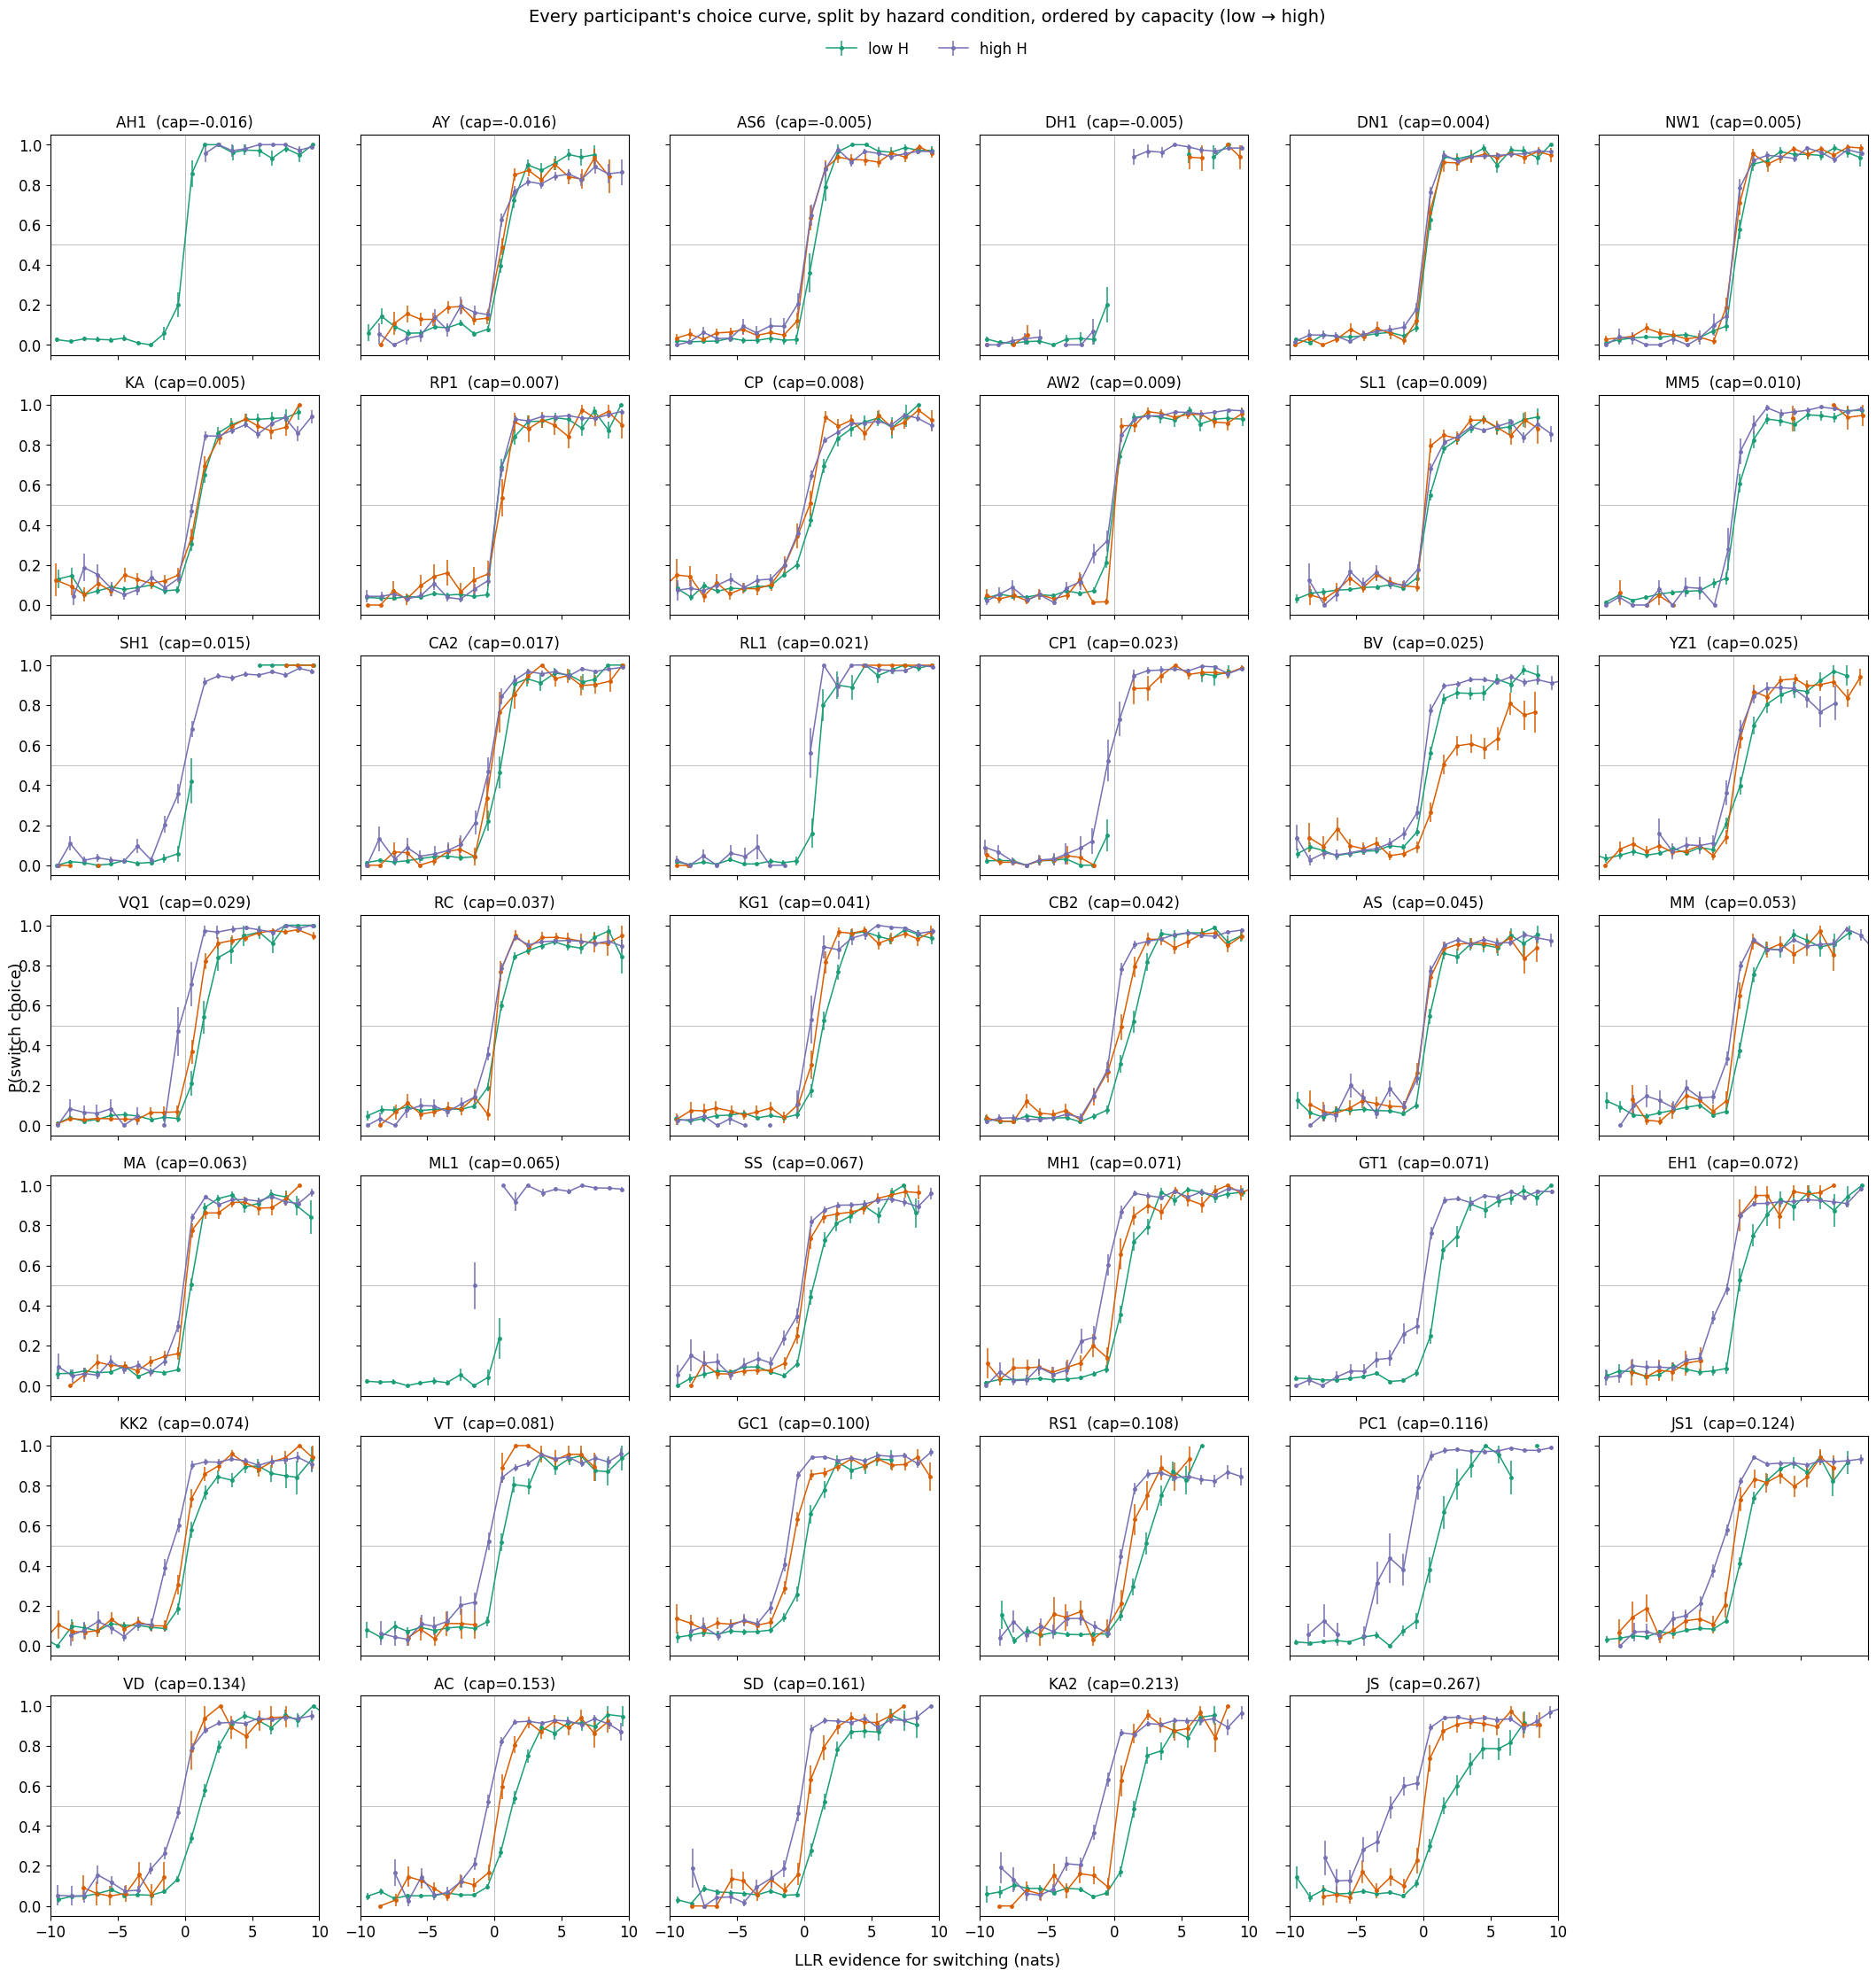

In [7]:
def mask_bin_gaps(c, p, se, max_gap=1.5):
    '''Insert NaNs where adjacent surviving bins are more than `max_gap`
    apart, so a sparse condition's plotted line breaks instead of drawing a
    misleading straight line across missing bins.'''
    if len(c) < 2:
        return c, p, se
    c2, p2, se2 = [c[0]], [p[0]], [se[0]]
    for i in range(1, len(c)):
        if c[i] - c[i - 1] > max_gap:
            c2.append(np.nan); p2.append(np.nan); se2.append(np.nan)
        c2.append(c[i]); p2.append(p[i]); se2.append(se[i])
    return np.array(c2), np.array(p2), np.array(se2)


order = capacity_df["subject"].tolist()
n_subj = len(order)
n_cols = 6
n_rows = int(np.ceil(n_subj / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3.6 * n_cols, 3.1 * n_rows), sharex=True, sharey=True
)
for ax, subj in zip(axes.ravel(), order):
    cap = capacity_df.loc[capacity_df.subject == subj, "capacity_bits"].item()
    for tier, label in HAZARD_TIER_NAMES.items():
        if tier not in curves_by_tier[subj]:
            continue
        c, p, se, n = curves_by_tier[subj][tier]
        c, p, se = mask_bin_gaps(c, p, se)
        ax.errorbar(c, p, yerr=se, fmt="o-", ms=2.5, lw=1.1, color=HAZARD_TIER_COLORS[tier], label=label)
    ax.axhline(0.5, color="0.75", lw=0.7, zorder=0)
    ax.axvline(0, color="0.75", lw=0.7, zorder=0)
    ax.set_title(f"{subj}  (cap={cap:.3f})", fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-10, 10)
    ax.tick_params(labelsize=12)

for ax in axes.ravel()[n_subj:]:
    ax.axis("off")

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.supxlabel("LLR evidence for switching (nats)", fontsize=13)
fig.supylabel("P(switch choice)", fontsize=13)
fig.suptitle("Every participant's choice curve, split by hazard condition, ordered by capacity (low → high)", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

### 2.3 Quantifying curve shape, and two corrections it needs

Two descriptive statistics, computed directly from a participant's binned curve, turn "does this look like a step" into a number:

- **Concentration ratio** — the single bin-to-bin jump straddling `LLR = 0`, divided by the curve's total rise. A pure step puts nearly its whole rise into that one jump (ratio near 1); a smooth sigmoid spreads its rise over several bins (ratio well below 1).
- **Slope kurtosis** — the excess kurtosis of the (rectified) bin-to-bin rises, treated as a distribution over LLR. A step's rise is one narrow spike (high kurtosis); a smooth sigmoid's rise is spread out (lower kurtosis).

In [8]:
def shape_stats(centers, p_switch, lo_edge=-10, hi_edge=10, max_bin_gap=1.5):
    '''Concentration ratio and slope kurtosis for a binned switching curve,
    restricted to its evenly spaced inner bins. Returns (nan, nan) if a gap
    wider than max_bin_gap separates surviving bins near the transition --
    otherwise a straight line bridging missing bins would read as an
    artificially smooth or sharp curve.'''
    inner = (centers > lo_edge) & (centers < hi_edge)
    c, p = centers[inner], p_switch[inner]
    if len(c) < 4:
        return np.nan, np.nan
    order_ = np.argsort(c)
    c, p = c[order_], p[order_]
    if np.any(np.diff(c) > max_bin_gap):
        return np.nan, np.nan

    i0 = np.searchsorted(c, 0)
    if not (0 < i0 < len(c)):
        return np.nan, np.nan
    central_jump = p[i0] - p[i0 - 1]
    total_rise = p[-2:].mean() - p[:2].mean()
    concentration_ratio = central_jump / total_rise if total_rise > 0 else np.nan

    rise = np.clip(np.diff(p), 0, None)  # local slope mass; clip the occasional noisy dip
    if rise.sum() <= 0:
        return concentration_ratio, np.nan
    x = (c[:-1] + c[1:]) / 2
    w = rise / rise.sum()
    mean_x = np.sum(w * x)
    var_x = np.sum(w * (x - mean_x) ** 2)
    slope_kurtosis = np.sum(w * (x - mean_x) ** 4) / var_x**2 - 3 if var_x > 0 else np.nan

    return concentration_ratio, slope_kurtosis


print("shape_stats defined")

shape_stats defined


Two things stand in the way of trusting either statistic at face value, and both need to be corrected for before the numbers mean what they're supposed to.

**1. Overall steepness.** Both statistics are computed on a fixed 1-nat bin grid, with no regard for how wide a participant's whole transition is. A perfectly smooth but simply *steep* curve dumps most of its rise into the one or two central bins — the same signature as a real step. And steepness itself is known to track capacity (2018 paper), through a mechanism (the width of someone's assumed hazard-rate range) that has nothing to do with how many belief levels they use. So a fixed-bin statistic could just be re-measuring steepness.

**The fix:** fit each participant's own logistic slope (`logit(P) = b0 + b1·llr_switch`, giving `slope_b1`) and re-express every trial's evidence on that fitted scale (`eta = b0 + b1·llr_switch`) before rebinning. On this rescaled axis a smooth logistic curve looks identical regardless of its original steepness — so anything that still looks step-shaped is genuine, not a narrow transition viewed through fixed-width bins.

A concrete illustration of why this has to be done *within* each hazard condition, not on trials pooled across conditions: fitting one slope per participant on all their trials pooled together gives a slope that correlates strongly with capacity (ρ = 0.627, p < 0.0001, printed below) — which looks like exactly the confound just described. But that relationship is manufactured by pooling: different hazard conditions call for different optimal steepness on their own, so mixing them inflates the apparent link. Fit separately within each condition and it mostly disappears (§3 confirms this per condition). This is the general reason nothing in this notebook is computed on hazard-pooled trials.

In [9]:
def fit_logistic(x, y, n_iter=100, tol=1e-10, ridge=1e-8):
    '''Two-parameter logistic regression of binary y on x (Newton-Raphson),
    returning (intercept b0, slope b1): logit(P(y=1|x)) = b0 + b1*x.'''
    X = np.column_stack([np.ones_like(x), x])
    beta = np.zeros(2)
    for _ in range(n_iter):
        eta = np.clip(X @ beta, -30, 30)
        p = 1 / (1 + np.exp(-eta))
        w = np.clip(p * (1 - p), 1e-10, None)
        grad = X.T @ (y - p)
        Hess = (X * w[:, None]).T @ X + ridge * np.eye(2)
        step = np.linalg.solve(Hess, grad)
        beta = beta + step
        if np.max(np.abs(step)) < tol:
            break
    return beta  # b0 (intercept), b1 (slope, per nat)


ETA_BIN_EDGES = np.r_[-40, np.arange(-8, 8.01, 0.8), 40]  # same bin count as EVIDENCE_BIN_EDGES

pooled_b1 = {}
for d in subjects:
    b0, b1 = fit_logistic(d["llr_switch"], d["switch"])
    pooled_b1[d["subject"]] = b1
pooled_b1_aligned = capacity_df["subject"].map(pooled_b1)
rho_pooled, p_pooled = spearmanr(capacity_df["capacity_bits"], pooled_b1_aligned)
print(f"pooled (hazard-collapsed) slope vs. capacity: rho={rho_pooled:+.3f}, p={p_pooled:.4f} -- an artifact of pooling, not evidence about capacity")

pooled (hazard-collapsed) slope vs. capacity: rho=+0.627, p=0.0000 -- an artifact of pooling, not evidence about capacity


**2. Finite-sample bias.** Slope-normalizing controls for steepness, but not for two other ways a curve could look step-shaped without reflecting how many belief levels someone uses: noise in exactly where one boundary sits, and the fact that concentration ratio and slope kurtosis, estimated from a few thousand trials, carry their own sampling bias. §3 builds the reference model needed to correct for both at once.

## 3. Result: capacity predicts curve shape, within two of three hazard conditions

### The reference floor

The most capacity-limited case possible is an observer with exactly two states — "currently believe left" or "currently believe right," nothing else carried between trials. Each trial, the evidence for switching is compared to a threshold, but fuzzily:

$$P(\text{flip belief}) = \text{sigmoid}\!\left(\frac{\text{llr}_{\text{switch}} - \theta(h)}{s}\right)$$

`s` is a free "fuzziness" parameter, completely decoupled from state count (there are always exactly two states, however small or large `s` is). `θ(h) = log((1-h)/h)` is not fit — it is the closed-form threshold at which a maximally confident belief flips, from Glaze et al.'s own recursion — so this reference model already includes the hazard-driven threshold-shift mechanism at no extra cost. Call this **Model A**: the minimum-capacity floor. If a real curve looks no different from Model A at a matching fuzziness, hazard rate, and trial count, there is no evidence in its shape for more than two belief levels; if it looks reliably different, that is real evidence of something beyond one fuzzy boundary.

In [10]:
import sys

sys.path.insert(0, str(Path.cwd().parent / "utilities"))
from intuitions import simulate_switching_sequence, emit_continuous


def simulate_model_A(h, s, T, seed, dprime):
    '''Two-state observer, closed-form hazard threshold, tunable fuzziness s.'''
    theta = np.log((1 - h) / h)
    rng = np.random.default_rng(seed)
    y = simulate_switching_sequence(T, h, rng)
    x = emit_continuous(y, dprime / 2, 1.0, rng)
    llr_x = dprime * x
    choice = np.empty(T, dtype=int)
    choice[0] = rng.integers(0, 2)
    for t in range(1, T):
        llr_own = llr_x[t] if choice[t - 1] == 0 else -llr_x[t]
        p_switch = 1 / (1 + np.exp(-(llr_own - theta) / s))
        choice[t] = 1 - choice[t - 1] if rng.random() < p_switch else choice[t - 1]
    prev_y = np.r_[np.nan, y[:-1]]
    llr_switch = np.where(prev_y == 0, llr_x, -llr_x)[1:]
    switch = (np.diff(choice) != 0).astype(float)
    return llr_switch, switch


def norm_shape(llr_switch, switch):
    '''concentration_ratio_norm/slope_kurtosis_norm for a simulated trace,
    via the same fit_logistic -> eta transform -> shape_stats pipeline used
    on real data.'''
    b0, b1 = fit_logistic(llr_switch, switch)
    eta = b0 + b1 * llr_switch
    ce, pe, _, _ = switch_curve(eta, switch, ETA_BIN_EDGES, min_n=30)
    cr_n, kurt_n = shape_stats(ce, pe, -8, 8)
    return cr_n, kurt_n, b1


tier_h_all = {t: [] for t in HAZARD_TIER_NAMES}
for d in subjects:
    for t in HAZARD_TIER_NAMES:
        tier_h_all[t].append(d["h_val"][d["hazard_tier"] == t])
tier_h_rep = {t: float(np.median(np.concatenate(v))) for t, v in tier_h_all.items()}
dprime_med = float(np.median([d["dprime"] for d in subjects]))
print(f"representative d': {dprime_med:.2f}")
print(f"representative hazard rate per condition: { {HAZARD_TIER_NAMES[t]: round(h, 3) for t, h in tier_h_rep.items()} }")

representative d': 2.82
representative hazard rate per condition: {'low H': 0.1, 'mid H': 0.5, 'high H': 0.9}


In [11]:
# Model A's concentration_ratio_norm should be invariant to s and h once
# well-sampled -- confirming it is a genuine "single fuzzy transition" floor,
# not an artifact of one particular noise level or hazard rate.
rows = []
for s in [0.5, 1.0, 1.5, 2.0]:
    llr_switch, switch = simulate_model_A(tier_h_rep[0], s, T=200_000, seed=1, dprime=dprime_med)
    cr_n, kurt_n, b1 = norm_shape(llr_switch, switch)
    rows.append(dict(sweep="s", value=s, concentration_ratio_norm=cr_n, fitted_b1=b1))
for h in [0.1, 0.3, 0.5, 0.7, 0.9]:
    llr_switch, switch = simulate_model_A(h, 1.5, T=200_000, seed=1, dprime=dprime_med)
    cr_n, kurt_n, b1 = norm_shape(llr_switch, switch)
    rows.append(dict(sweep="h", value=h, concentration_ratio_norm=cr_n, fitted_b1=b1))
print(pd.DataFrame(rows).round(3).to_string(index=False))

sweep  value  concentration_ratio_norm  fitted_b1
    s    0.5                     0.446      0.423
    s    1.0                     0.415      0.345
    s    1.5                     0.429      0.263
    s    2.0                     0.446      0.200
    h    0.1                     0.429      0.263
    h    0.3                     0.469      0.280
    h    0.5                     0.426      0.280
    h    0.7                     0.432      0.282
    h    0.9                     0.451      0.268


`concentration_ratio_norm` sits in a tight band (≈0.43) no matter which fuzziness or hazard rate generated the curve — slope-normalizing does map any single logistic transition onto the same canonical shape. (Separately confirmed, not re-run here: swapping the 2-state readout for a fully continuous, unlimited-capacity accumulator gives the same floor — so this reflects "one transition," not "two states" specifically.)

Real participants have far fewer trials than the 200,000 used above, so it matters whether this floor is estimated reliably at realistic sample sizes:

In [12]:
T_REALISTIC = 3600  # ~ the low-H condition's median real trial count
null_check = []
for seed in range(1, 201):
    llr_switch, switch = simulate_model_A(tier_h_rep[0], 1.5, T=T_REALISTIC, seed=seed, dprime=dprime_med)
    cr_n, _, _ = norm_shape(llr_switch, switch)
    null_check.append(cr_n)
null_check = pd.Series(null_check, dtype=float).dropna()
print(f"T={T_REALISTIC}: mean={null_check.mean():.3f}  sd={null_check.std():.3f}  "
      f"5-95th pct=[{null_check.quantile(.05):.3f}, {null_check.quantile(.95):.3f}]  "
      f"99th pct={null_check.quantile(.99):.3f}  max={null_check.max():.3f}")

T=3600: mean=0.482  sd=0.078  5-95th pct=[0.383, 0.587]  99th pct=0.778  max=0.847


That spread is comparable to the entire real population's observed range, from nothing but resampling noise around a floor that never actually changes. A fair comparison therefore can't use one fixed floor value — each participant's statistic has to be compared to a null built at *their own* trial count, fitted fuzziness (`s = 1/slope_b1`), and hazard rate, separately in each condition. That personalized null is what the rest of this section builds: 150 Model-A replicates per participant × condition, converting each observed statistic into a z-score against its own null.

In [13]:
tier_shape_rows = []
for d in subjects:
    subj = d["subject"]
    cap = capacity_df.loc[capacity_df.subject == subj, "capacity_bits"].item()
    for tier, (c, p, se, n) in curves_by_tier[subj].items():
        cr, kurt = shape_stats(c, p)
        in_tier = d["hazard_tier"] == tier
        b0_t, b1_t = fit_logistic(d["llr_switch"][in_tier], d["switch"][in_tier])
        eta_t = b0_t + b1_t * d["llr_switch"][in_tier]
        ce_t, pe_t, se_t, n_t = switch_curve(eta_t, d["switch"][in_tier], edges=ETA_BIN_EDGES)
        cr_n, kurt_n = shape_stats(ce_t, pe_t, lo_edge=-8, hi_edge=8)
        tier_shape_rows.append(dict(
            subject=subj, hazard_tier=HAZARD_TIER_NAMES[tier], tier_idx=tier, capacity_bits=cap,
            n_trials=int(in_tier.sum()), slope_b1=b1_t, concentration_ratio=cr, slope_kurtosis=kurt,
            concentration_ratio_norm=cr_n, slope_kurtosis_norm=kurt_n,
        ))

tier_shape_df = pd.DataFrame(tier_shape_rows)

print(f"{'condition':9s} {'metric':26s} {'n':>3s} {'rho':>7s} {'p':>8s}")
for tier in HAZARD_TIER_NAMES.values():
    sub = tier_shape_df[tier_shape_df.hazard_tier == tier]
    for metric in ["slope_b1", "concentration_ratio_norm", "slope_kurtosis_norm"]:
        ok = sub[metric].notna()
        rho, pval = spearmanr(sub.loc[ok, "capacity_bits"], sub.loc[ok, metric])
        print(f"{tier:9s} {metric:26s} {ok.sum():3d} {rho:+7.3f} {pval:8.4f}")
    print()

condition metric                       n     rho        p
low H     slope_b1                    41  -0.040   0.8036
low H     concentration_ratio_norm    40  -0.408   0.0089
low H     slope_kurtosis_norm         40  -0.065   0.6907

mid H     slope_b1                    37  +0.322   0.0518
mid H     concentration_ratio_norm    32  +0.041   0.8235
mid H     slope_kurtosis_norm         32  -0.450   0.0097

high H    slope_b1                    41  +0.068   0.6706
high H    concentration_ratio_norm    39  -0.528   0.0006
high H    slope_kurtosis_norm         39  -0.063   0.7016



Within each hazard condition on its own, slope no longer reliably tracks capacity (unlike the pooled ρ=0.627 above) — confirming that relationship was a pooling artifact, not a real confound to correct for here.

In [14]:
N_NULL = 150
MIN_S = 0.3  # floor on s=1/b1 to avoid pathological near-zero-slope rows

null_rows = []
for i, row in tier_shape_df.iterrows():
    if not np.isfinite(row.concentration_ratio_norm) or not np.isfinite(row.slope_b1) or row.slope_b1 <= 0:
        null_rows.append(dict(null_mean=np.nan, null_sd=np.nan, z=np.nan))
        continue
    h = tier_h_rep[row.tier_idx]
    s = max(1.0 / row.slope_b1, MIN_S)
    T = int(row.n_trials)
    null_crs = []
    for rep in range(N_NULL):
        llr_switch, switch = simulate_model_A(h, s, T=T, seed=10_000 * i + rep, dprime=dprime_med)
        cr_n, _, _ = norm_shape(llr_switch, switch)
        null_crs.append(cr_n)
    null_crs = np.array(null_crs, dtype=float)
    null_crs = null_crs[np.isfinite(null_crs)]
    if len(null_crs) < N_NULL // 2:
        null_rows.append(dict(null_mean=np.nan, null_sd=np.nan, z=np.nan))
        continue
    null_mean, null_sd = null_crs.mean(), null_crs.std(ddof=1)
    z = (row.concentration_ratio_norm - null_mean) / null_sd if null_sd > 0 else np.nan
    null_rows.append(dict(null_mean=null_mean, null_sd=null_sd, z=z))

tier_shape_df = pd.concat([tier_shape_df.reset_index(drop=True), pd.DataFrame(null_rows)], axis=1)
print(f"{len(tier_shape_df)} rows null-calibrated")

119 rows null-calibrated


In [15]:
print(f"{'condition':9s} {'n':>3s} {'obs.median':>10s} {'floor.median':>12s} {'z.median':>9s} "
      f"{'sharper':>7s} {'smoother':>8s} {'raw rho':>9s} {'z rho':>9s}")
for tier in HAZARD_TIER_NAMES.values():
    sub = tier_shape_df[tier_shape_df.hazard_tier == tier]
    ok = sub.z.notna()
    rho_raw, p_raw = spearmanr(sub.loc[ok, "capacity_bits"], sub.loc[ok, "concentration_ratio_norm"])
    rho_z, p_z = spearmanr(sub.loc[ok, "capacity_bits"], sub.loc[ok, "z"])
    n_sharp = int((sub.loc[ok, "z"] > 1.645).sum())
    n_smooth = int((sub.loc[ok, "z"] < -1.645).sum())
    print(f"{tier:9s} {ok.sum():3d} {sub.loc[ok,'concentration_ratio_norm'].median():10.3f} "
          f"{sub.loc[ok,'null_mean'].median():12.3f} {sub.loc[ok,'z'].median():9.3f} "
          f"{n_sharp:7d} {n_smooth:8d} {rho_raw:+9.3f} {rho_z:+9.3f}")
    print(f"          raw p={p_raw:.4f}, null-corrected p={p_z:.4f}")

condition   n obs.median floor.median  z.median sharper smoother   raw rho     z rho
low H      40      0.478        0.681    -1.387       1       16    -0.408    -0.319
          raw p=0.0089, null-corrected p=0.0451
mid H      32      0.680        0.491     2.174      17        1    +0.041    -0.139
          raw p=0.8235, null-corrected p=0.4470
high H     39      0.550        0.728    -1.216       0       10    -0.528    -0.393
          raw p=0.0006, null-corrected p=0.0135


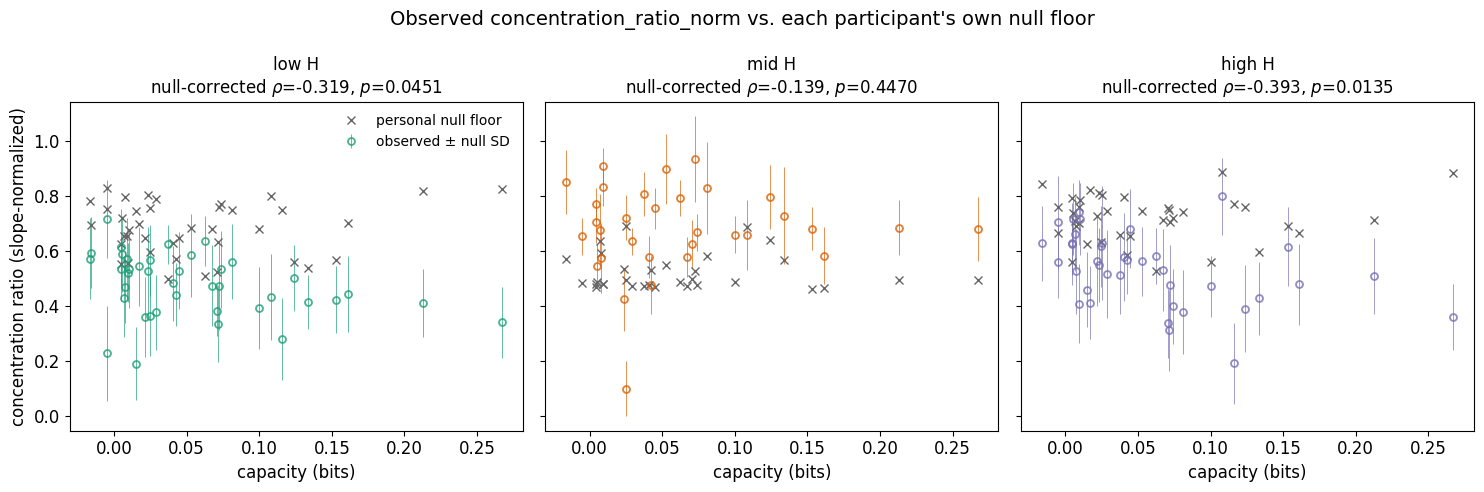

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, tier in zip(axes, HAZARD_TIER_NAMES.values()):
    sub = tier_shape_df[tier_shape_df.hazard_tier == tier]
    ok = sub.z.notna()
    color = HAZARD_TIER_COLORS[list(HAZARD_TIER_NAMES.values()).index(tier)]
    ax.errorbar(sub.loc[ok, "capacity_bits"], sub.loc[ok, "concentration_ratio_norm"],
                yerr=sub.loc[ok, "null_sd"], fmt="o", ms=5, mec=color, mfc="none", mew=1.3,
                ecolor=color, elinewidth=0.6, alpha=0.8, label="observed ± null SD")
    ax.plot(sub.loc[ok, "capacity_bits"], sub.loc[ok, "null_mean"], "x", color="0.4", ms=6,
             label="personal null floor")
    rho_z, p_z = spearmanr(sub.loc[ok, "capacity_bits"], sub.loc[ok, "z"])
    ax.set_title(f"{tier}\nnull-corrected $\\rho$={rho_z:.3f}, $p$={p_z:.4f}", fontsize=12)
    ax.set_xlabel("capacity (bits)")
axes[0].set_ylabel("concentration ratio (slope-normalized)")
axes[0].legend(frameon=False, fontsize=10, loc="upper right")
fig.suptitle("Observed concentration_ratio_norm vs. each participant's own null floor", fontsize=14)
fig.tight_layout()
plt.show()

### Reading the result

**The capacity relationship survives, weakened, in low and high H; mid H stays null.** Comparing each participant's statistic to their own personalized null removes most, but not all, of the raw relationship: low H goes from ρ=-0.408 (p=0.0089) raw to ρ=-0.319 (p=0.045) corrected; high H from ρ=-0.528 (p=0.0006) to ρ=-0.393 (p=0.014). Both stay significant and in the same direction — genuine evidence that curve shape tracks capacity beyond what sampling noise around a fixed floor would produce, though weaker than the raw numbers suggested. Mid H shows nothing either way (raw ρ=+0.041, p=0.82; corrected ρ=-0.139, p=0.45), consistent with every version of this check.

**Almost nobody is individually "step-like."** Only 1 of 40 low-H participants and 0 of 39 high-H participants have a statistic significantly *above* their own floor — essentially the false-positive rate expected by chance. What's common is the opposite: 16/40 (low H) and 10/39 (high H) are significantly *below* their floor, i.e. reliably smoother than a bare 2-state, fuzzy-boundary observer would produce, and by more the higher their capacity. Mid H shows the reverse individual pattern (17/32 significantly *sharper*, 1 smoother) but, again, with no capacity relationship attached to it — it doesn't obviously belong to the same story as the other two conditions.

**So the finding is "excess smoothness beyond a two-state floor, scaling with capacity," not "a sharper step at lower capacity."** Nobody's curve is a literal two-level step; two levels is the noise floor everyone sits at or above, and higher capacity buys measurable extra smoothness past it, in the low- and high-hazard conditions specifically.

## 4. What an optimal capacity-limited model predicts

An explicit model makes a sharper prediction than a descriptive statistic can. This section simulates the actual capacity-limited observer built for this task in `02_triangles.ipynb` (`utilities/ib_core.py`, `intuitions.py`): a `k`-state machine whose belief "rung" updates every trial, built to be the best possible `k`-state summary of the evidence for this task's own hazard rate and `d′` (signal-detection discriminability, from each participant's real triangle separation and noise). Capacity is varied by sweeping `k` from 2 to 12 states.

Two choices behind this model are worth stating plainly. First, it reports its belief probabilistically (`P(switch) = q[\text{rung}]`, "probability matching") rather than with a hard 50% threshold — a hard threshold barely responds to `k` at all at this task's signal strength, since one observation is usually decisive; probability matching is what lets the number of belief levels actually show up in behavior. Second, hazard rate shifts *where* the curve transitions, not just how steep it is (rarer switches need more evidence before committing, so the low-H curve's crossing point sits above zero; frequent switches need less, so high-H sits below zero) — this is itself one of the 2018 paper's findings, and the model reproduces it automatically. Because of this shift, only the slope-normalized statistics from §3 (which center on each curve's own fitted transition point) are valid for comparing a single hazard condition; the raw, zero-centered version would just measure noise on the shoulder of a shifted curve.

In [17]:
from intuitions import discretize_gaussian, bin_index, get_optimal_fsm, simulate_ladder_path

tier_n_all = {t: 0 for t in HAZARD_TIER_NAMES}
for d in subjects:
    for t in HAZARD_TIER_NAMES:
        tier_n_all[t] += int((d["hazard_tier"] == t).sum())
n_total = sum(tier_n_all.values())
tier_weight = {t: tier_n_all[t] / n_total for t in HAZARD_TIER_NAMES}
print(f"tier trial-count weights: { {HAZARD_TIER_NAMES[t]: round(w, 3) for t, w in tier_weight.items()} }")

disc = discretize_gaussian(nlev=9, mu=dprime_med / 2, sigma=1.0)


def simulate_model_curve(k, T_per_tier=60_000, seed=1):
    '''Simulate a k-state, probability-matching IB-optimal observer in each
    hazard condition separately (each read out by its own condition-optimal
    k-state machine). Returns pooled per-trial arrays (for the binless
    capacity measure) and a per-condition breakdown for the switch curve.'''
    rng = np.random.default_rng(seed)
    choice_all, x_bin_all, h_bin_all, llr_feat_all = [], [], [], []
    llr_switch_all, switch_all = [], []
    by_tier = {}
    for tier_idx, (tier, h_rep) in enumerate(tier_h_rep.items()):
        H = np.array([[1 - h_rep, h_rep], [h_rep, 1 - h_rep]])
        fsm = get_optimal_fsm(k, disc["P"], H, n_restarts=8, seed=seed)
        f, q = fsm["f"], fsm["q"]

        T = max(int(T_per_tier * tier_weight[tier] / min(tier_weight.values())), 2000)
        y = simulate_switching_sequence(T, h_rep, rng)
        x = emit_continuous(y, dprime_med / 2, 1.0, rng)
        lev = bin_index(x, disc["edges"])
        r = simulate_ladder_path(f, lev, r0=k // 2)
        choice = (rng.random(T) < q[r]).astype(int)  # probability-matching readout

        llr_x = dprime_med * x  # true continuous LLR favoring y=1

        choice_all.append(choice)
        x_bin_all.append((x >= 0).astype(int))
        h_bin_all.append(np.full(T, tier_idx))
        llr_feat_all.append(llr_x)

        prev_y = np.r_[np.nan, y[:-1]]
        llr_switch = np.where(prev_y == 0, llr_x, -llr_x)[1:]
        switch = (np.diff(choice) != 0).astype(float)
        llr_switch_all.append(llr_switch)
        switch_all.append(switch)
        by_tier[tier] = dict(llr_switch=llr_switch, switch=switch)

    return dict(
        choice=np.concatenate(choice_all), x_bin=np.concatenate(x_bin_all), h_bin=np.concatenate(h_bin_all),
        llr_feat=np.concatenate(llr_feat_all),
        llr_switch=np.concatenate(llr_switch_all), switch=np.concatenate(switch_all), by_tier=by_tier,
    )


print("model machinery ready")

tier trial-count weights: {'low H': 0.457, 'mid H': 0.132, 'high H': 0.411}
model machinery ready


In [18]:
K_GRID = [2, 3, 4, 6, 8, 12]

model_curves_tier = {}  # k -> {tier -> (centers, p_switch, se, n)}
model_rows, model_tier_rows = [], []

for k in K_GRID:
    sim = simulate_model_curve(k)

    model_capacity_bits = (
        predictive_info_ksg(sim["llr_feat"], sim["choice"], hazard=sim["h_bin"])
        - predictive_info_ksg(sim["llr_feat"], sim["x_bin"], hazard=sim["h_bin"])
    )
    model_rows.append(dict(k=k, model_capacity_bits=model_capacity_bits))

    model_curves_tier[k] = {}
    for tier, chunk in sim["by_tier"].items():
        model_curves_tier[k][tier] = switch_curve(chunk["llr_switch"], chunk["switch"], EVIDENCE_BIN_EDGES, min_n=30)
        b0t, b1t = fit_logistic(chunk["llr_switch"], chunk["switch"])
        etat = b0t + b1t * chunk["llr_switch"]
        cet, pet, _, _ = switch_curve(etat, chunk["switch"], ETA_BIN_EDGES, min_n=30)
        cret, kurtet = shape_stats(cet, pet, -8, 8)
        model_tier_rows.append(dict(
            k=k, hazard_tier=HAZARD_TIER_NAMES[tier], model_capacity_bits=model_capacity_bits,
            concentration_ratio_norm=cret, slope_kurtosis_norm=kurtet,
        ))

model_df = pd.DataFrame(model_rows)
model_tier_df = pd.DataFrame(model_tier_rows)
print(model_df.round(3).to_string(index=False))

 k  model_capacity_bits
 2                0.115
 3                0.150
 4                0.183
 6                0.199
 8                0.214
12                0.217


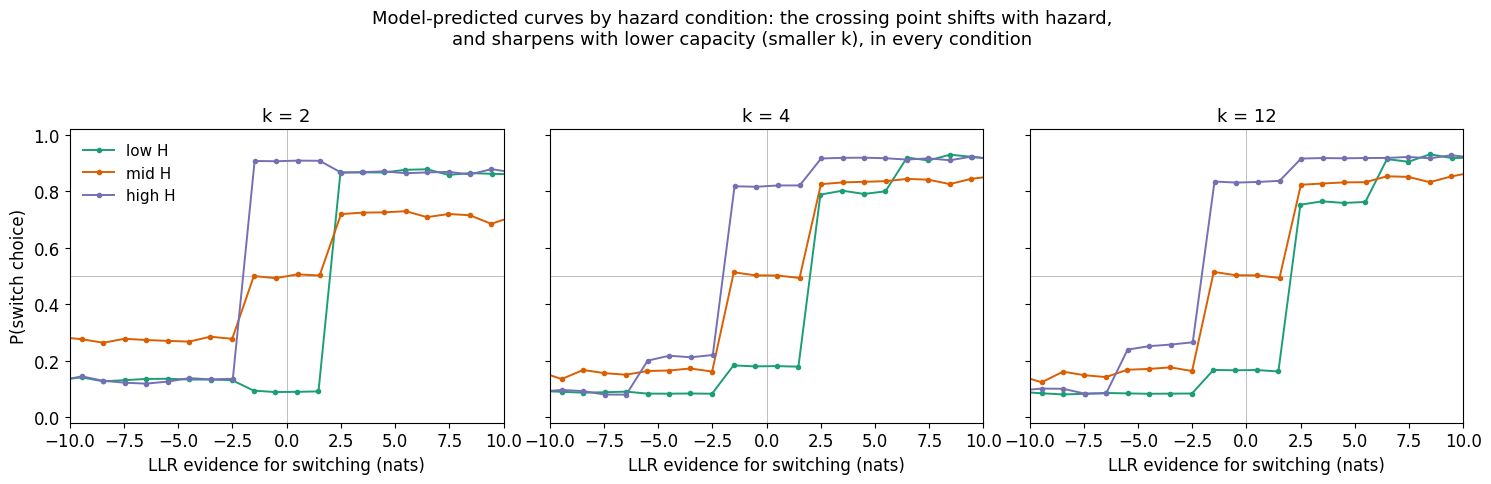

In [19]:
k_examples = [2, 4, 12]
fig, axes = plt.subplots(1, len(k_examples), figsize=(5 * len(k_examples), 4.6), sharey=True)
for ax, k in zip(axes, k_examples):
    for tier, label in HAZARD_TIER_NAMES.items():
        c, p, se, n = model_curves_tier[k][tier]
        ax.plot(c, p, "o-", ms=3, lw=1.4, color=HAZARD_TIER_COLORS[tier], label=label)
    ax.axhline(0.5, color="0.75", lw=0.7, zorder=0)
    ax.axvline(0, color="0.75", lw=0.7, zorder=0)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"k = {k}", fontsize=13)
    ax.set_xlabel("LLR evidence for switching (nats)")
axes[0].set_ylabel("P(switch choice)")
axes[0].legend(frameon=False, fontsize=11, loc="upper left")
fig.suptitle("Model-predicted curves by hazard condition: the crossing point shifts with hazard,\nand sharpens with lower capacity (smaller k), in every condition", fontsize=13, y=1.05)
fig.tight_layout()
plt.show()

low H: model range [0.115, 0.217] bits, concentration_ratio_norm 0.448-0.622
  real participants: median capacity 0.041 bits, concentration_ratio_norm median 0.478
  6 of 40 real participants fall inside the model's tested capacity range: their concentration_ratio_norm is 0.279-0.501 (median 0.418)
mid H: model range [0.115, 0.217] bits, concentration_ratio_norm 0.262-0.658
  real participants: median capacity 0.037 bits, concentration_ratio_norm median 0.680
  5 of 32 real participants fall inside the model's tested capacity range: their concentration_ratio_norm is 0.583-0.795 (median 0.684)
high H: model range [0.115, 0.217] bits, concentration_ratio_norm 0.442-0.624
  real participants: median capacity 0.041 bits, concentration_ratio_norm median 0.550
  6 of 39 real participants fall inside the model's tested capacity range: their concentration_ratio_norm is 0.191-0.616 (median 0.453)


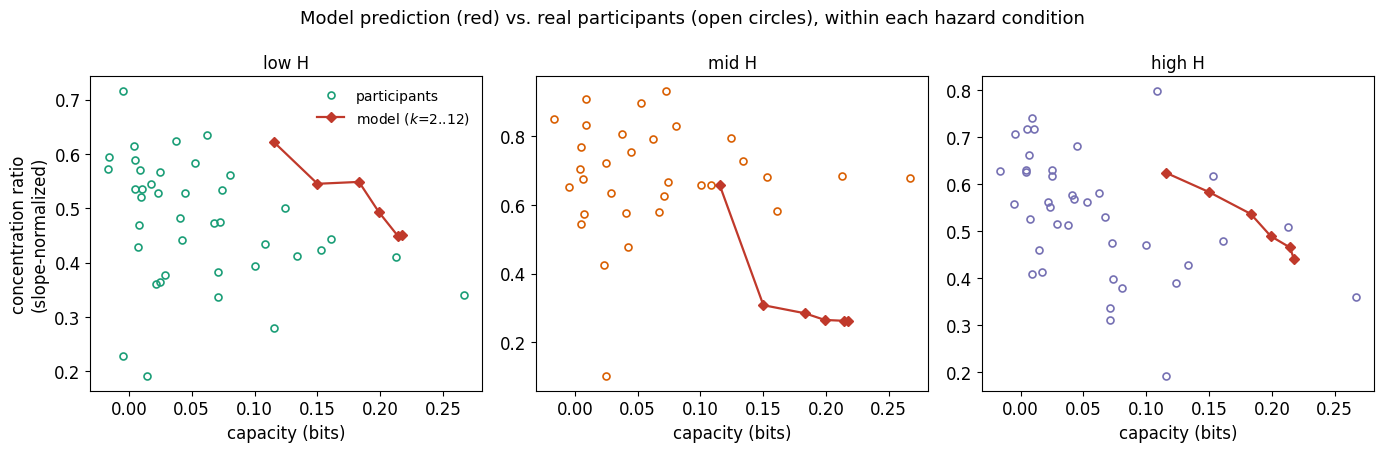

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharex=True)
for col, tier in enumerate(HAZARD_TIER_NAMES.values()):
    ax = axes[col]
    sub_data = tier_shape_df[tier_shape_df.hazard_tier == tier]
    ok = sub_data["concentration_ratio_norm"].notna()
    ax.plot(sub_data.loc[ok, "capacity_bits"], sub_data.loc[ok, "concentration_ratio_norm"],
             "o", mfc="none", mec=HAZARD_TIER_COLORS[list(HAZARD_TIER_NAMES.values()).index(tier)],
             mew=1.2, ms=5, zorder=1, label="participants")
    sub_model = model_tier_df[model_tier_df.hazard_tier == tier].sort_values("model_capacity_bits")
    ax.plot(sub_model["model_capacity_bits"], sub_model["concentration_ratio_norm"], "D-", color="#c0392b", ms=5, lw=1.6, zorder=2, label="model ($k$=2..12)")
    ax.set_title(tier, fontsize=12)
    ax.set_xlabel("capacity (bits)")
    if col == 0:
        ax.set_ylabel("concentration ratio\n(slope-normalized)")
        ax.legend(frameon=False, fontsize=10)
    model_lo, model_hi = sub_model.model_capacity_bits.min(), sub_model.model_capacity_bits.max()
    matched = sub_data[sub_data.capacity_bits.between(model_lo, model_hi) & sub_data.concentration_ratio_norm.notna()]
    print(f"{tier}: model range [{model_lo:.3f}, {model_hi:.3f}] bits, "
          f"concentration_ratio_norm {sub_model.concentration_ratio_norm.min():.3f}-{sub_model.concentration_ratio_norm.max():.3f}")
    print(f"  real participants: median capacity {sub_data.capacity_bits.median():.3f} bits, "
          f"concentration_ratio_norm median {sub_data.concentration_ratio_norm.median():.3f}")
    if len(matched):
        print(f"  {len(matched)} of {ok.sum()} real participants fall inside the model's tested capacity range: "
              f"their concentration_ratio_norm is {matched.concentration_ratio_norm.min():.3f}-{matched.concentration_ratio_norm.max():.3f} "
              f"(median {matched.concentration_ratio_norm.median():.3f})")
    else:
        print(f"  0 of {ok.sum()} real participants fall inside the model's tested capacity range")

fig.suptitle("Model prediction (red) vs. real participants (open circles), within each hazard condition", fontsize=13)
fig.tight_layout()
plt.show()

**The model gets the direction right, in every condition:** its own `concentration_ratio_norm` falls as its own capacity rises, matching the real relationship in §3, on top of reproducing the hazard-driven crossing-point shift for free.

**The magnitude comparison is not one story — it's a different story in each hazard condition.** Very few real participants have enough capacity to fall inside the range the model was even tested at: 6 of 40 in low H, 5 of 32 in mid H, 6 of 39 in high H (counts printed above). Restricting to just those matched participants: in **low H** they are *smoother* than the model predicts at the same capacity (real median 0.418 vs. the model's 0.448–0.622 — the opposite of "the model under-resolves"); in **mid H** they are *sharper* than the model's sharpest prediction (real median 0.684 vs. model max 0.658); in **high H** the two overlap (real median 0.453, inside the model's 0.442–0.624). With only 5–6 matched participants per condition, none of this supports a precise magnitude estimate — but it does rule out a single, condition-general "the model under-resolves" story. Whichever way the gap points, it points differently depending on hazard rate.

One thing this comparison does not yet do: put the model's own curves through the same null-correction §3 applies to real data. Its curves come from 60,000+ simulated trials per condition, so finite-sample bias should be far smaller there than in the real data — but not exactly zero, and it hasn't been checked directly. That is a natural next step (§6) before treating the matched-subset numbers above as final.

## 5. Two ideas for the model's within-capacity erosion

Regardless of how the magnitude comparison in §4 nets out, one thing about the model itself is worth explaining on its own: an information-maximizing search's curve gets steadily smoother as `k` grows (visible in §4's model curve). Why: `get_optimal_fsm` searches for the `k`-state machine maximizing total shared information between belief and category, with no term for *where* those bits go. This task's hazard rates make the belief accumulator's stationary occupancy strongly bimodal — mostly confident one way or the other, with near-boundary belief rare and brief. An objective that only counts total bits, applied to bimodal occupancy, spends its extra states resolving the two common confident regions rather than the rare boundary — so more capacity mostly buys a smoother, not sharper, curve.

Two ideas for changing that, **both tested only at the low-hazard condition's true rate** — not yet checked at mid or high hazard, so treat the conclusions below as limited to that one condition until they are. The reference band in both plots below is the real low-H population's whole observed range (not the small, capacity-matched subset used in §4 — a different, complementary comparison):

1. **Assume participants overestimate the hazard rate.** A higher assumed switch rate would make the accumulator's belief distribution less bimodal, giving an information-maximizing search a reason to resolve the boundary.
2. **Replace the search objective with decision accuracy.** Total shared information treats every error the same; what should matter is that an error made while already confident costs little, while one near a genuine close call costs more. `ib_core.fsm_scores` provides `acc_filter`, the exact Bayes/MAP accuracy of predicting the category from the belief rung, as a drop-in alternative search target.

In [21]:
H_SWEEP = [tier_h_rep[0], 0.2, 0.3, 0.4, 0.5]  # true low-hazard rate, then increasingly inflated
K_SWEEP_H = [2, 4]
low_h_real = tier_shape_df.loc[tier_shape_df.hazard_tier == "low H", "concentration_ratio_norm"].dropna()


def simulate_model_curve_h(k, h, T=80_000, seed=1, target="I_filter"):
    '''Single-hazard-rate counterpart of simulate_model_curve: one condition
    at a time, so h and the search target can both be swept independently.'''
    H = np.array([[1 - h, h], [h, 1 - h]])
    fsm = get_optimal_fsm(k, disc["P"], H, n_restarts=8, seed=seed, target=target)
    f, q = fsm["f"], fsm["q"]

    rng = np.random.default_rng(seed)
    y = simulate_switching_sequence(T, h, rng)
    x = emit_continuous(y, dprime_med / 2, 1.0, rng)
    lev = bin_index(x, disc["edges"])
    r = simulate_ladder_path(f, lev, r0=k // 2)
    choice = (rng.random(T) < q[r]).astype(int)

    llr_x = dprime_med * x
    prev_y = np.r_[np.nan, y[:-1]]
    llr_switch = np.where(prev_y == 0, llr_x, -llr_x)[1:]
    switch = (np.diff(choice) != 0).astype(float)
    return llr_switch, switch


h_sweep_curves, h_sweep_rows = {}, []
for k in K_SWEEP_H:
    for h in H_SWEEP:
        llr_switch, switch = simulate_model_curve_h(k, h)
        c, p, se, n = switch_curve(llr_switch, switch, EVIDENCE_BIN_EDGES, min_n=30)
        b0, b1 = fit_logistic(llr_switch, switch)
        eta = b0 + b1 * llr_switch
        ce, pe, se_e, ne = switch_curve(eta, switch, ETA_BIN_EDGES, min_n=30)
        cr_n, kurt_n = shape_stats(ce, pe, -8, 8)
        h_sweep_curves[(k, h)] = (c, p, se, n)
        h_sweep_rows.append(dict(k=k, h=h, concentration_ratio_norm=cr_n, slope_kurtosis_norm=kurt_n))

h_sweep_df = pd.DataFrame(h_sweep_rows)
print(f"real low-H concentration_ratio_norm range: [{low_h_real.min():.3f}, {low_h_real.max():.3f}], median {low_h_real.median():.3f}")
print(h_sweep_df.round(3).to_string(index=False))

real low-H concentration_ratio_norm range: [0.190, 0.717], median 0.478
 k   h  concentration_ratio_norm  slope_kurtosis_norm
 2 0.1                     0.617                5.609
 2 0.2                     0.871                8.974
 2 0.3                     1.004               17.970
 2 0.4                     0.636                0.226
 2 0.5                     0.643                0.546
 4 0.1                     0.562                6.035
 4 0.2                     0.569                2.978
 4 0.3                     0.341                2.305
 4 0.4                     0.300               -0.431
 4 0.5                     0.283                1.226


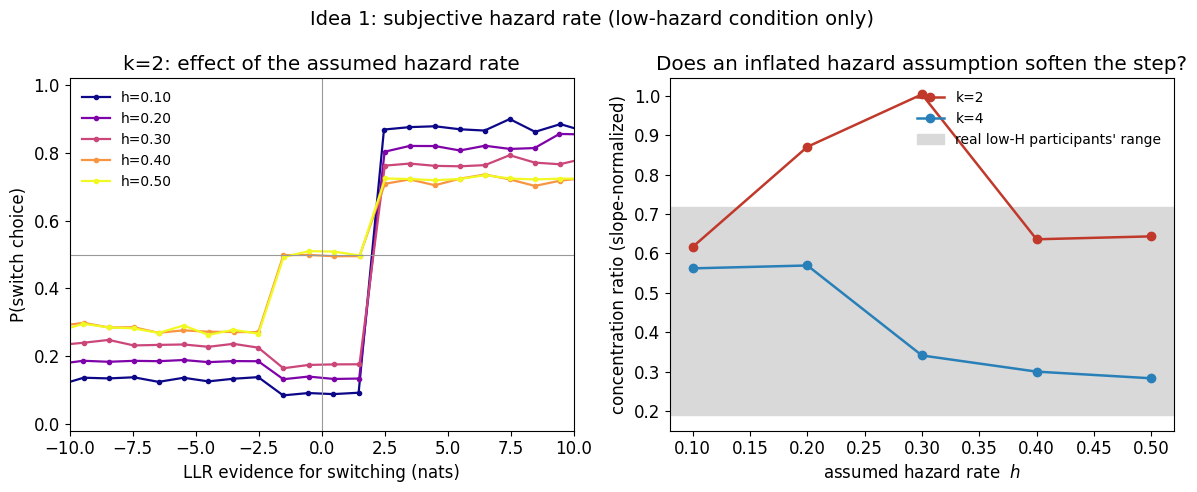

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
h_cmap = plt.cm.plasma
h_norm = plt.Normalize(min(H_SWEEP), max(H_SWEEP))
k_fixed = 2
for h in H_SWEEP:
    c, p, se, n = h_sweep_curves[(k_fixed, h)]
    ax.plot(c, p, "o-", ms=3, lw=1.6, color=h_cmap(h_norm(h)), label=f"h={h:.2f}")
ax.axhline(0.5, color="0.6", lw=0.8)
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlim(-10, 10)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("LLR evidence for switching (nats)")
ax.set_ylabel("P(switch choice)")
ax.set_title(f"k={k_fixed}: effect of the assumed hazard rate")
ax.legend(frameon=False, fontsize=10)

ax = axes[1]
for k, color in zip(K_SWEEP_H, ["#c0392b", "#2980b9"]):
    sub = h_sweep_df[h_sweep_df.k == k].sort_values("h")
    ax.plot(sub.h, sub.concentration_ratio_norm, "o-", color=color, ms=6, lw=1.8, label=f"k={k}")
ax.axhspan(low_h_real.min(), low_h_real.max(), color="0.85", zorder=0, label="real low-H participants' range")
ax.set_xlabel("assumed hazard rate  $h$")
ax.set_ylabel("concentration ratio (slope-normalized)")
ax.set_title("Does an inflated hazard assumption soften the step?")
ax.legend(frameon=False, fontsize=10)

fig.suptitle("Idea 1: subjective hazard rate (low-hazard condition only)", fontsize=14)
fig.tight_layout()
plt.show()

**Idea 1 does not hold up.** At `k=2`, only two belief states exist regardless of the assumed hazard rate, so there's no slack for a higher assumed rate to buy graded resolution — the curve stays close to a literal step at every rate tested. At `k=4`, raising the assumed rate does soften the curve, but in the wrong direction: the true-hazard model already sits close to the real low-H median, and every larger assumed rate pushes it further below that median, not closer to it.

In [23]:
K_SWEEP_ACC = [2, 3, 4, 6, 8, 12]
h_true_low = tier_h_rep[0]

acc_curves, acc_rows = {}, []
for k in K_SWEEP_ACC:
    for target in ["I_filter", "acc_filter"]:
        llr_switch, switch = simulate_model_curve_h(k, h_true_low, target=target)
        c, p, se, n = switch_curve(llr_switch, switch, EVIDENCE_BIN_EDGES, min_n=30)
        b0, b1 = fit_logistic(llr_switch, switch)
        eta = b0 + b1 * llr_switch
        ce, pe, se_e, ne = switch_curve(eta, switch, ETA_BIN_EDGES, min_n=30)
        cr_n, kurt_n = shape_stats(ce, pe, -8, 8)
        acc_curves[(k, target)] = (c, p, se, n)
        acc_rows.append(dict(k=k, target=target, concentration_ratio_norm=cr_n, slope_kurtosis_norm=kurt_n))

acc_df = pd.DataFrame(acc_rows)
print(acc_df.round(3).to_string(index=False))

 k     target  concentration_ratio_norm  slope_kurtosis_norm
 2   I_filter                     0.617                5.609
 2 acc_filter                     0.617                5.609
 3   I_filter                     0.623                8.747
 3 acc_filter                     0.547                8.820
 4   I_filter                     0.562                6.035
 4 acc_filter                     0.616                4.951
 6   I_filter                     0.510                4.658
 6 acc_filter                     0.620                5.603
 8   I_filter                     0.472                5.163
 8 acc_filter                     0.565                7.230
12   I_filter                     0.469                4.860
12 acc_filter                     0.652                9.522


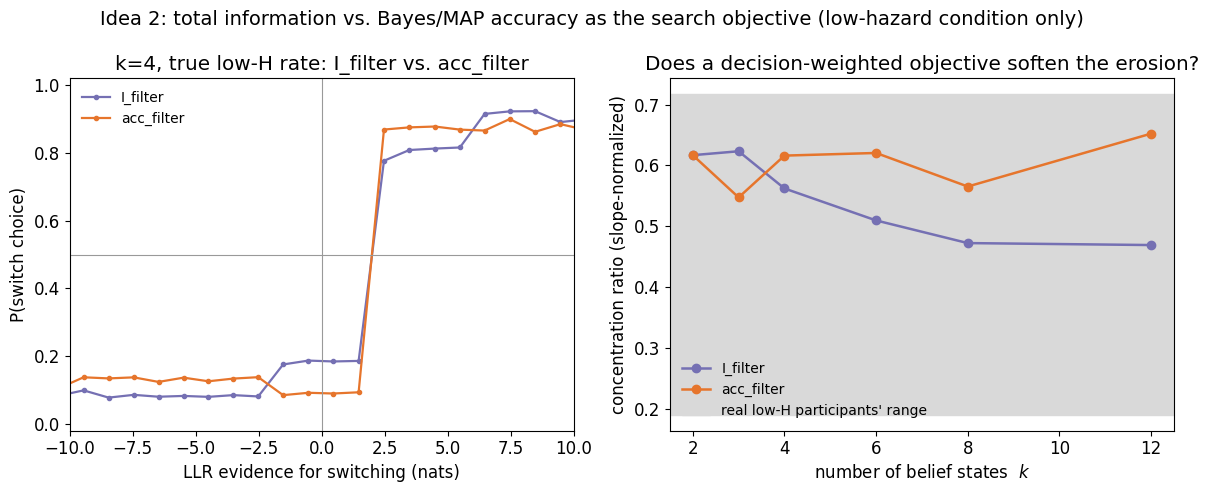

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
k_fixed = 4
for target, color in zip(["I_filter", "acc_filter"], ["#7570b3", "#e6752c"]):
    c, p, se, n = acc_curves[(k_fixed, target)]
    ax.plot(c, p, "o-", ms=3, lw=1.6, color=color, label=target)
ax.axhline(0.5, color="0.6", lw=0.8)
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlim(-10, 10)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("LLR evidence for switching (nats)")
ax.set_ylabel("P(switch choice)")
ax.set_title(f"k={k_fixed}, true low-H rate: I_filter vs. acc_filter")
ax.legend(frameon=False, fontsize=10)

ax = axes[1]
for target, color in zip(["I_filter", "acc_filter"], ["#7570b3", "#e6752c"]):
    sub = acc_df[acc_df.target == target].sort_values("k")
    ax.plot(sub.k, sub.concentration_ratio_norm, "o-", color=color, ms=6, lw=1.8, label=target)
ax.axhspan(low_h_real.min(), low_h_real.max(), color="0.85", zorder=0, label="real low-H participants' range")
ax.set_xlabel("number of belief states  $k$")
ax.set_ylabel("concentration ratio (slope-normalized)")
ax.set_title("Does a decision-weighted objective soften the erosion?")
ax.legend(frameon=False, fontsize=10)

fig.suptitle("Idea 2: total information vs. Bayes/MAP accuracy as the search objective (low-hazard condition only)", fontsize=14)
fig.tight_layout()
plt.show()

**Idea 2 works, partially, with a real trade-off.** At `k=2` the two objectives coincide (only one boundary to place). From `k=3` up, `acc_filter` keeps `concentration_ratio_norm` roughly flat as `k` grows, while the original total-information objective erodes steadily — `acc_filter` mostly stops the model from over-smoothing as it's given more states. The cost: this also removes most of the capacity-dependence that made the original model's *direction* correct in §4. A model that's both close in magnitude and still tracks capacity likely needs a blend of the two objectives, or fitting the blend (or the hazard assumption from Idea 1) per participant — not yet tried.

As in §3, the real-data comparison band above uses the raw, not null-corrected, statistic, so it is approximate in the same way as §4's comparison.

## 6. Summary and open questions

**Settled.** Capacity predicts curve shape in the low- and high-hazard conditions (null-corrected ρ=-0.319, p=0.045 and ρ=-0.393, p=0.014), not in mid-hazard. The right description is "more capacity buys more excess smoothness beyond a minimal two-state floor," not "less capacity produces a sharper step" — essentially no participant is individually sharper than that floor. An explicit capacity-limited model reproduces the *direction* of this relationship in every condition, for an identifiable reason (an information-maximizing search spends extra states on already-confident regions, not on rare near-boundary evidence). Its *magnitude*, compared against the handful of real participants whose capacity actually overlaps what the model was tested at, does not point the same way in every condition — real participants are smoother than the model in low H, sharper in mid H, and comparable in high H — so "the model under-resolves" is not a general finding here, whatever else it may be. Separately, the model's curve reliably gets smoother as its own capacity grows (§5) — assuming participants overestimate the hazard rate makes this worse, not better; switching the search objective to decision accuracy mostly stops it, but at the cost of the model's capacity-dependence. Given §4's finding, neither idea should be read as "closing the gap" in general — only as addressing that one specific within-model mechanism.

**Open:**

- §4's magnitude comparison restricts to capacity-matched participants (a real fix over comparing mismatched capacity ranges), but still measures the real side with the raw, not null-corrected, statistic, and the model side hasn't been checked for its own finite-sample bias. Both matter more now that the matched comparison is a per-condition, 5-6-participant result rather than a clean population-wide one.
- Idea 1 and Idea 2 (§5) were tested only at the low-hazard rate, and only address the model's own within-capacity erosion — not the tier-dependent magnitude picture in §4. Whether either conclusion holds at mid or high hazard is untested.
- Given §4's finding that the magnitude gap isn't consistently signed, "fixing" the model likely needs different adjustments in different hazard conditions rather than one global recipe — not yet explored.
- Whether "capacity" here is a stable trait or a condition-specific artifact of hazard-rate mismatch (Glaze et al.'s own account of individual differences) is untested: it would show up as the same participants ranking similarly across all three hazard conditions (trait account) vs. ranking well only in conditions whose true rate is far from some shared assumed rate (mismatch account).
- No correction for multiple comparisons across the many condition × statistic combinations checked here.
- Curve error bars are binomial, not bootstrapped; the model's curves in §4–§5 come from single simulation runs, with no uncertainty band across seeds.
- The binless capacity estimator has somewhat higher per-participant variance than the binned version it replaced (`02b_capacity_estimators.ipynb`) — not large enough to change anything here, but relevant for analyses sensitive to small per-participant differences.